In [2]:
import ee
import geemap
import ipyleaflet


In [3]:
# Authenticate and initialize Earth Engine
ee.Authenticate()



True

In [4]:
ee.Initialize(project='ee-jandrewgoldman')

In [5]:
# Load the NBAC raster
nbac_raster = ee.Image("projects/sat-io/open-datasets/CA_FOREST/NBAC/NBAC_MRB_1972_to_2023")

# Load Ontario boundary (assuming the image has a 'year' band with burn year values)
ontario = ee.FeatureCollection("FAO/GAUL/2015/level1").filter(ee.Filter.eq('ADM1_NAME', 'Ontario'))

# Clip the raster to Ontario
nbac_ontario = nbac_raster.clip(ontario)

# Define visualization parameters
# Define visualization parameters
palette = [
    # 1970s (1972-1979) - Blues
    '#08519c', '#2171b5', '#4292c6', '#6baed6', '#9ecae1', '#c6dbef', '#deebf7', '#f7fbff',
    
    # 1980s - Greens
    '#006d2c', '#2ca25f', '#66c2a4', '#99d8c9', '#ccece6', '#edf8fb', '#238b45', '#41ab5d', '#74c476', '#a1d99b',
    
    # 1990s - Purples to Reds
    '#54278f', '#756bb1', '#9e9ac8', '#bcbddc', '#dadaeb', '#7a0177', '#ae017e', '#dd3497', '#f768a1', '#fa9fb5',
    
    # 2000s - Orange to Yellow
    '#8c2d04', '#cc4c02', '#ec7014', '#fe9929', '#fec44f', '#fee391', '#fff7bc', '#ffffe5', '#d95f0e', '#fe9929',
    
    # 2010s - Multiple hues
    '#a63603', '#e6550d', '#fd8d3c', '#fdae6b', '#fdd0a2', '#31a354', '#74c476', '#a1d99b', '#c7e9c0', '#e5f5e0',
    
    # 2020s - Ending with distinct colors
    '#756bb1', '#88419d', '#8c6bb1', '#810f7c', '#4d004b'
]

vis_params = {
    'min': 1972,
    'max': 2023,
    'palette': palette
}
Map = geemap.Map()
Map.add_basemap("Stamen.Toner")
Map.centerObject(ontario, 6)
Map.addLayer(nbac_ontario, vis_params, 'Fires in Ontario (1972-2023)')

# Add a colorbar legend
Map.add_colorbar(vis_params, label='Burn Year')

# Display the map
Map

Map(center=[50.33480090546707, -85.71776327672706], controls=(WidgetControl(options=['position', 'transparent_…

In [7]:
# Download the clipped NBAC raster to local file (reduced resolution for manageability)
geemap.download_ee_image(nbac_ontario, 'nbac_ontario.tif', scale=1000, crs='EPSG:4326')

nbac_ontario.tif: |          | 0.00/190M (raw) [  0.0%] in 00:00 (eta:     ?)

There is no STAC entry for: projects/sat-io/open-datasets/CA_FOREST/NBAC/NBAC_MRB_1972_to_2023


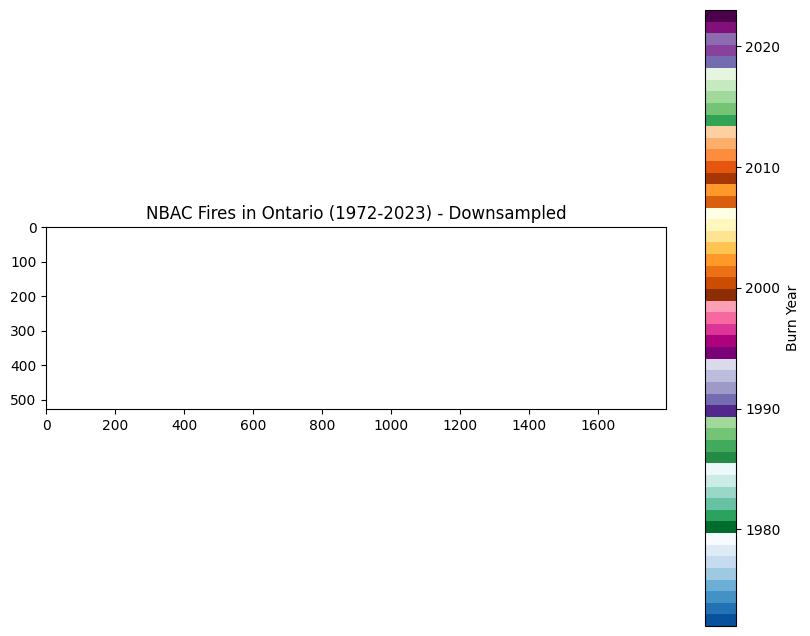

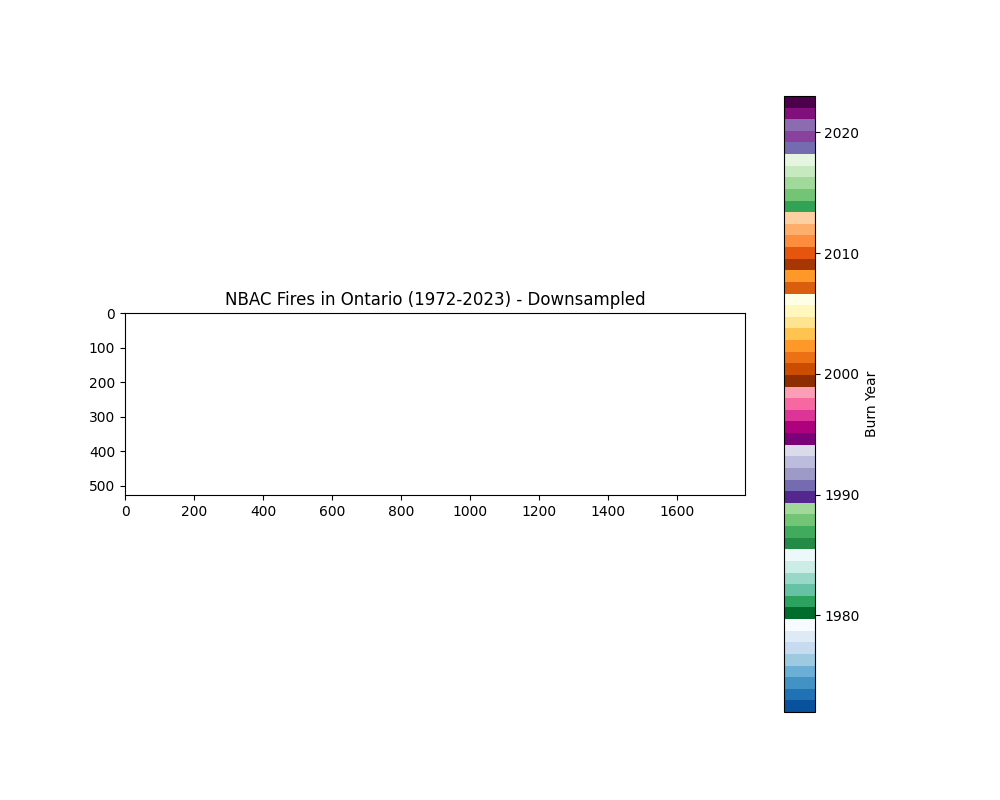

In [14]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from IPython.display import display, Image

# Define the colormap from the palette
cmap = ListedColormap(palette)

# Open and plot the downloaded raster
with rasterio.open('nbac_ontario.tif') as src:
    data = src.read(1).astype(float)
    data[data == 0] = np.nan  # Assume 0 is no data
    
    # Downsample for plotting (reduce resolution to make it manageable)
    data = data[::10, ::10]
    
    plt.figure(figsize=(10, 8))
    # Use standard cmap for testing
    plt.imshow(data, cmap='viridis', vmin=1972, vmax=2023)
    plt.colorbar(label='Burn Year')
    plt.title('NBAC Fires in Ontario (1972-2023) - Test with Viridis')
    plt.savefig('nbac_plot.png')
    plt.show()

# Display the saved image
display(Image('nbac_plot.png'))

In [10]:
%matplotlib inline

In [ ]:
import geemap

# Download the clipped NBAC raster to local file (reduced resolution for manageability)
geemap.download_ee_image(nbac_ontario, 'nbac_ontario.tif', scale=1000, region=ontario.geometry(), crs='EPSG:4326')